# Mass–Spring–Damper System Simulation

This notebook investigates the continuous-time and discrete-time simulation of a second-order mass–spring–damper system.

The governing differential equation is

$$
m\ddot{x}(t) + b\dot{x}(t) + kx(t) = f(t)
$$

where:

- $m$ is the mass in kg,
- $b$ is the viscous damping coefficient in N·s/m,
- $k$ is the spring stiffness in N/m,
- $f(t)$ is the applied force in N,
- $x(t)$ is the position in m.

Velocity is defined as

$$
v(t) = \dot{x}(t)
$$

The second-order differential equation can therefore be rewritten as two first-order equations:

$$
\dot{x}(t) = v(t)
$$

and

$$
\dot{v}(t)
=
-\frac{k}{m}x(t)
-\frac{b}{m}v(t)
+\frac{1}{m}f(t)
$$

## State-Space Representation

The exercise slide uses the state ordering

$$
\mathbf{x}_{\text{slide}}(t)
=
\begin{bmatrix}
v(t) \\
x(t)
\end{bmatrix}
$$

With this ordering, the state-space equation is

$$
\begin{bmatrix}
\dot{v}(t) \\
\dot{x}(t)
\end{bmatrix}
=
\begin{bmatrix}
-\frac{b}{m} & -\frac{k}{m} \\
1 & 0
\end{bmatrix}
\begin{bmatrix}
v(t) \\
x(t)
\end{bmatrix}
+
\begin{bmatrix}
\frac{1}{m} \\
0
\end{bmatrix}
f(t)
$$

In this notebook, the state vector is arranged as

$$
\mathbf{x}(t)
=
\begin{bmatrix}
x(t) \\
v(t)
\end{bmatrix}
$$

This ordering is convenient in Python because the first state is position and the second state is velocity.

The corresponding state-space equation is

$$
\dot{\mathbf{x}}(t)
=
A\mathbf{x}(t)
+
Bf(t)
$$

where

$$
A
=
\begin{bmatrix}
0 & 1 \\
-\frac{k}{m} & -\frac{b}{m}
\end{bmatrix}
$$

and

$$
B
=
\begin{bmatrix}
0 \\
\frac{1}{m}
\end{bmatrix}
$$

Therefore,

$$
\begin{bmatrix}
\dot{x}(t) \\
\dot{v}(t)
\end{bmatrix}
=
\begin{bmatrix}
0 & 1 \\
-\frac{k}{m} & -\frac{b}{m}
\end{bmatrix}
\begin{bmatrix}
x(t) \\
v(t)
\end{bmatrix}
+
\begin{bmatrix}
0 \\
\frac{1}{m}
\end{bmatrix}
f(t)
$$

Both state-space representations describe the same physical system. The only difference is the order of the state variables.

For the exercise parameters

$$
m = 1, \qquad b = 1, \qquad k = 10
$$

the matrices used in this notebook become

$$
A
=
\begin{bmatrix}
0 & 1 \\
-10 & -1
\end{bmatrix}
$$

and

$$
B
=
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

## Objectives

1. Simulate the continuous-time system using Forward Euler integration.
2. Discretize the system using the matrix exponential.
3. Compare the Euler and exact discrete-time solutions.
4. Investigate how the time-step size affects numerical accuracy.

In [ ]:
import numpy as np # vectors, matrices, time arrays, matrix multiplications, storing the simulation results
import matplotlib.pyplot as plt

## System Parameters

The mass–spring–damper model is

$$
m\ddot{x}(t) + b\dot{x}(t) + kx(t) = f(t)
$$

For this exercise, the system parameters are

$$
m = 1\ \text{kg}
$$

$$
b = 1\ \text{N·s/m}
$$

$$
k = 10\ \text{N/m}
$$

The applied force is a unit-step input:

$$
f(t) = 1\ \text{N}, \qquad t \geq 0
$$

The initial conditions are

$$
x(0) = 0\ \text{m}
$$

$$
v(0) = 0\ \text{m/s}
$$

The continuous-time simulation will run for

$$
T = 10\ \text{s}
$$

using the Euler integration time step

$$
\Delta t = 0.01\ \text{s}
$$

In [4]:
# Physical system parameters 
m = 1.0  # Mass in kilograms 
b = 1.0 # Damping coefficient in N.s/m 
k = 10.0 # Spring stiffness in N/m 

#Input force
force = 1.0 # unit-step force in newtons 

#Initial conditions 
x0 = 0.0 # initial position in meters 
v0 = 0.0 # initial velocity in meters per seconds 

# Simulation parameters 
dt = 0.01 # Euler integration time step in seconds 
t_final = 10.0


In [7]:
print(f"Mass: {m} kg")
print(f"Damping coefficient: {b} N·s/m")
print(f"Spring stiffness: {k} N/m")
print(f"Force: {force} N")
print(f"Time step: {dt} s")
print(f"Final simulation time: {t_final} s")

Mass: 1.0 kg
Damping coefficient: 1.0 N·s/m
Spring stiffness: 10.0 N/m
Force: 1.0 N
Time step: 0.01 s
Final simulation time: 10.0 s


## Continuous-Time State-Space Model

The state vector used in this notebook is

$$
\mathbf{x}(t)
=
\begin{bmatrix}
x(t) \\
v(t)
\end{bmatrix}
$$

where $x(t)$ is position and $v(t)$ is velocity.

The state-space equation has the form

$$
\dot{\mathbf{x}}(t)
=
A\mathbf{x}(t) + Bf(t)
$$

For the mass–spring–damper system,

$$
A
=
\begin{bmatrix}
0 & 1 \\
-\frac{k}{m} & -\frac{b}{m}
\end{bmatrix}
$$

and

$$
B
=
\begin{bmatrix}
0 \\
\frac{1}{m}
\end{bmatrix}
$$

The first row of the model represents

$$
\dot{x}(t) = v(t)
$$

The second row represents

$$
\dot{v}(t)
=
-\frac{k}{m}x(t)
-\frac{b}{m}v(t)
+\frac{1}{m}f(t)
$$

For $m=1$, $b=1$, and $k=10$, the matrices become

$$
A
=
\begin{bmatrix}
0 & 1 \\
-10 & -1
\end{bmatrix}
$$

and

$$
B
=
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

In [10]:
# Continuous-time state matrix 
A = np.array([[0.0, 1.0],[-k/m, -b/m]])

# Continous-time input matrix 
B = np.array([[0.0],[1.0 / m]])

# Initial state vector: [position, velocity]
state_initial = np.array([[x0], [v0]])

print("A Matrix")
print(A)

print("\nB Matrix")
print(B)

print("\nInitial state vector:")
print(state_initial)

print("\nMatrix dimensions:")
print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"Initial state shape: {state_initial.shape}")

A Matrix
[[  0.   1.]
 [-10.  -1.]]

B Matrix
[[0.]
 [1.]]

Initial state vector:
[[0.]
 [0.]]

Matrix dimensions:
A shape: (2, 2)
B shape: (2, 1)
Initial state shape: (2, 1)


In [13]:
state_derivative_initial = A @ state_initial + B * force # @ performs matrix multiplication 

print("Initial state derivative:")
print(state_derivative_initial)

print(f"\nInitial position derivative: {state_derivative_initial[0,0]:.2f} m/s")
print(f"Initial velocity derivative: {state_derivative_initial[1,0]:.2f} m/s^2")

Initial state derivative:
[[0.]
 [1.]]

Initial position derivative: 0.00 m/s
Initial velocity derivative: 1.00 m/s^2


## Time Discretization

A continuous-time model evolves at every instant of time. A computer, however, evaluates the model only at discrete time points.

The simulation time step is

$$
\Delta t = 0.01\ \text{s}
$$

and the final simulation time is

$$
T = 10\ \text{s}
$$

The discrete time points are

$$
t_0 = 0,\quad
t_1 = \Delta t,\quad
t_2 = 2\Delta t,\quad
\dots,\quad
t_N = T
$$

The number of simulation intervals is

$$
N = \frac{T}{\Delta t}
$$

For this exercise,

$$
N = \frac{10}{0.01} = 1000
$$

Because the simulation includes both the initial time $t=0$ and the final time $t=T$, the time array contains

$$
N+1 = 1001
$$

samples.

In [17]:
# Number of simulation intevals N = T (end of simulation time) / time step (dt) 
num_steps = int(t_final / dt)

# Time vector including both t = 0 and t = t_final 
time = np.linspace(0.0, t_final, num_steps + 1) # +1 because one more interval is necessary for next number

print(f"Number of intervals: {num_steps}")
print(f"Number of time samples: {len(time)}")
print(f"Initial time: {time[0]:.2f} s")
print(f"Final time: {time[-1]:.2f} s")
print(f"Computed time step: {time[1] - time[0]:.4f} s")

Number of intervals: 1000
Number of time samples: 1001
Initial time: 0.00 s
Final time: 10.00 s
Computed time step: 0.0100 s


In [21]:
# Allocate memory for the complete state history 
state_history = np.zeros((2, len(time)))
# Store the intiial condition in the first column
state_history[:, 0] = state_initial[:,0]
print("\nInitial stored state:")
print(state_history[:,0])


Initial stored state:
[0. 0.]


## Forward Euler Integration

The continuous-time state-space model is

$$
\dot{\mathbf{x}}(t)
=
A\mathbf{x}(t) + Bf(t)
$$

The derivative $\dot{\mathbf{x}}(t)$ describes how quickly the state changes at the current time.

Using the Forward Euler method, the next state is approximated by

$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k
+
\Delta t\,\dot{\mathbf{x}}_k
$$

Substituting the state-space equation gives

$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k
+
\Delta t
\left(
A\mathbf{x}_k + Bf_k
\right)
$$

The Euler method assumes that the state derivative remains approximately constant during one small time interval $\Delta t$.

For the state vector

$$
\mathbf{x}_k
=
\begin{bmatrix}
x_k \\
v_k
\end{bmatrix},
$$

the update equations are

$$
x_{k+1}
=
x_k + \Delta t\,v_k
$$

and

$$
v_{k+1}
=
v_k
+
\Delta t
\left(
-\frac{k}{m}x_k
-\frac{b}{m}v_k
+\frac{1}{m}f_k
\right)
$$

In [26]:
# Interpreation of the Euler Forward Method 
# New value = current value + time step x current rate of change 

# Forward Euler Simulation 
for step in range(num_steps): # N = T/dt There are 1000 intervals so there are 1000 euler updates

    # Current state: [position, velocity]
    current_state = state_history[:, step] # current state comes from the state history that we allocated [:, len(time)]

    # State derivative from the continous-time model 
    state_derivative = A @ current_state + B[:, 0] * force 

    # Forward Euler Update
    next_state = current_state + dt * state_derivative

    # Store the next state 
    state_history[:, step + 1] = next_state

In [27]:
print("Initial state:")
print(state_history[:, 0])

print("\nState after one Euler step:")
print(state_history[:, 1])

print("\nState after two Euler steps:")
print(state_history[:, 2])

Initial state:
[0. 0.]

State after one Euler step:
[0.   0.01]

State after two Euler steps:
[0.0001 0.0199]


In [29]:
# Extract the two state variables 
position_euler = state_history[0, :]
velocity_euler = state_history[1, :]

print(f"Final position: {position_euler[-1]:.6f} m")
print(f"Final velocity: {velocity_euler[-1]:.6f} m/s")

Final position: 0.098920 m
Final velocity: -0.000154 m/s


## Expected Dynamic Response

The system parameters are

$$
m = 1,\qquad b = 1,\qquad k = 10
$$

The undamped natural frequency is

$$
\omega_n = \sqrt{\frac{k}{m}}
$$

For this system,

$$
\omega_n = \sqrt{10}
$$

The damping ratio is

$$
\zeta = \frac{b}{2\sqrt{km}}
$$

For the selected parameters,

$$
\zeta = \frac{1}{2\sqrt{10}}
$$

Since

$$
0 < \zeta < 1,
$$

the system is underdamped.

Therefore, we expect the position to:

1. rise from zero,
2. overshoot the steady-state value,
3. oscillate around the equilibrium position,
4. gradually settle because of damping.

For a constant input force, the steady-state position is

$$
x_{\mathrm{ss}} = \frac{f}{k}
$$

Therefore,

$$
x_{\mathrm{ss}} = \frac{1}{10} = 0.1\ \text{m}
$$

In [31]:
# Physical characteristics of the system 
natural_frequency = np.sqrt(k/m)
damping_ratio = b / (2.0 * np.sqrt(k*m))
steady_state_position = force / k

print(f'Natural freqency: {natural_frequency:.4f} rad/s')
print(f'Damping ratio: {damping_ratio:.4f}')
print(f'Steady-state position: {steady_state_position:.4f} m')

Natural freqency: 3.1623 rad/s
Damping ratio: 0.1581
Steady-state position: 0.1000 m


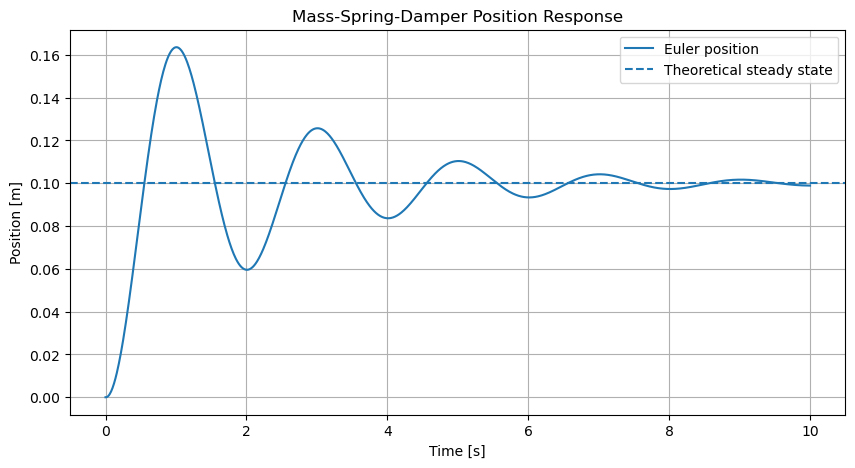

In [33]:
# Plot position versus time 
plt.figure(figsize = (10, 5))

plt.plot(time, position_euler, label = 'Euler position')
plt.axhline(steady_state_position, linestyle = "--", label = "Theoretical steady state")

plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Mass-Spring-Damper Position Response")
plt.grid(True)
plt.legend()
plt.show()

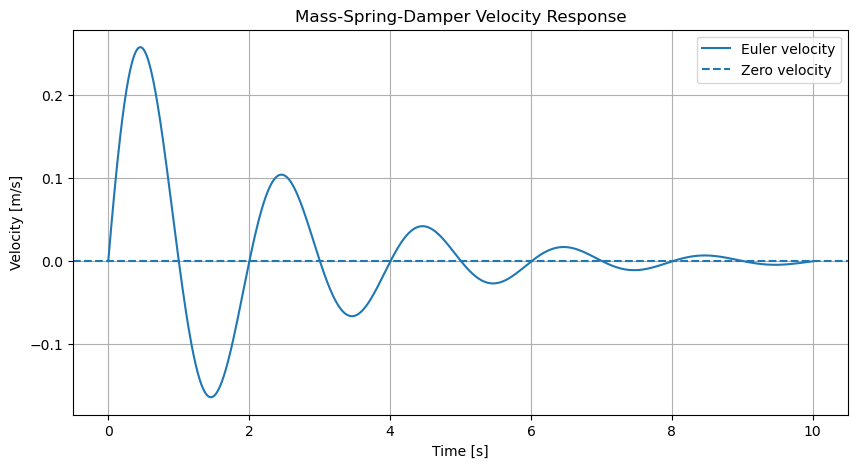

In [35]:
plt.figure(figsize=(10,5))
plt.plot(time, velocity_euler, label = "Euler velocity")
plt.axhline(0.0, linestyle = "--", label = "Zero velocity")

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Mass-Spring-Damper Velocity Response")
plt.grid(True)
plt.legend()
plt.show()

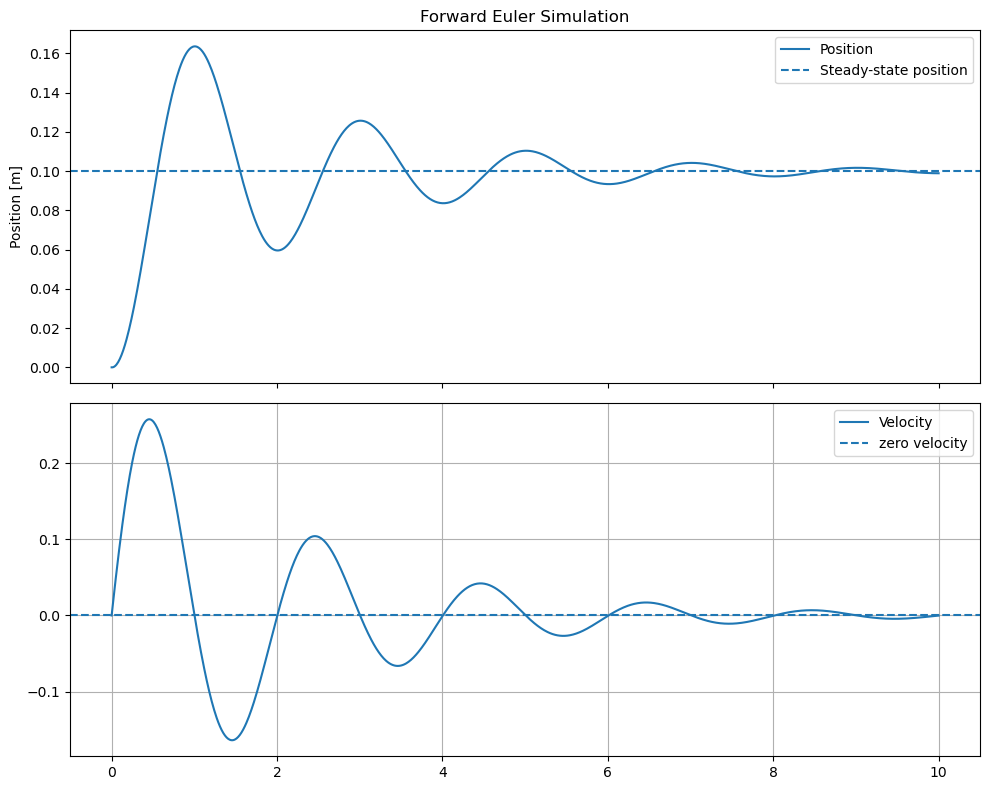

In [37]:
fig, axes = plt.subplots(nrows=2, ncols = 1, figsize = (10,8), sharex = True)
axes[0].plot(time, position_euler, label = "Position")
axes[0].axhline(steady_state_position, linestyle = "--", label = "Steady-state position")

axes[0].set_ylabel("Position [m]")
axes[0].set_title("Forward Euler Simulation")
axes[0].legend()

axes[1].plot(time, velocity_euler, label = "Velocity")
axes[1].axhline(0.0, linestyle = "--", label = "zero velocity")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
position_error = abs(position_euler[-1] - steady_state_position)
velocity_error = abs(velocity_euler[-1])

print(f"Final simulated position: {position_euler[-1]:.6f} m")
print(f"Theoritical steady-state position: {steady_state_position:.6f} m")
print(f"Final position error: {position_error:.6e} m")

print()

print(f"Final simulated velocity: {velocity_euler[-1]:.6f} m/s")
print(f"Final velocity magnitude: {velocity_error:.6e} m/s")

Final simulated position: 0.098920 m
Theoritical steady-state position: 0.100000 m
Final position error: 1.079705e-03 m

Final simulated velocity: -0.000154 m/s
Final velocity magnitude: 1.544580e-04 m/s


## Conclusion

The mass–spring–damper system was represented using the continuous-time state-space model

$$
\dot{\mathbf{x}}(t)
=
A\mathbf{x}(t)+Bf(t)
$$

with the state vector

$$
\mathbf{x}(t)
=
\begin{bmatrix}
x(t) \\
v(t)
\end{bmatrix}
$$

The continuous-time model was simulated numerically using the Forward Euler method:

$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k
+
\Delta t
\left(
A\mathbf{x}_k+Bf_k
\right)
$$

Forward Euler approximates the state evolution using the derivative evaluated at the beginning of each time interval.

For the selected parameters, the system is underdamped. Therefore, the position oscillates before gradually approaching the theoretical steady-state value

$$
x_{\mathrm{ss}}
=
\frac{f}{k}
=
0.1\ \text{m}
$$

while the velocity approaches zero.

The simulation demonstrates how a continuous-time differential equation can be solved numerically using a sequence of small time steps. The accuracy of the Forward Euler result depends on the selected time-step size.